In [3]:
!pip install mlxtend --quiet

In [4]:
from google.colab import files
import pandas as pd
import numpy as np
import os

print("1) LÜTFEN VERİ DOSYANIZI SEÇİN (kozmetik_surdurulebilir_churn_veri.xlsx):")
yuklenen = files.upload()

dosya_adi = list(yuklenen.keys())[0]
uzanti = os.path.splitext(dosya_adi)[1].lower()
print(f"\n[✓] '{dosya_adi}' yüklendi. İşlem tablosu okunuyor...\n")

# Islem_Tablosu ilk sayfadır; xlsx ise sheet adını açıkça veriyoruz
if uzanti in ['.xlsx', '.xls']:
    df_islem = pd.read_excel(dosya_adi, sheet_name='Islem_Tablosu')
else:
    df_islem = pd.read_csv(dosya_adi)

df_islem.columns = df_islem.columns.str.strip()
df_islem['urun_listesi'] = df_islem['sepetteki_urunler'].apply(
    lambda x: [i.strip() for i in str(x).split(',') if i.strip()])

toplam_islem = len(df_islem)
df_islem['sepet_boyutu'] = df_islem['urun_listesi'].apply(len)
tum_urunler = [u for liste in df_islem['urun_listesi'] for u in liste]
benzersiz_urunler = sorted(set(tum_urunler))

print("=== AŞAMA B0: BETİMSEL SEPET METRİKLERİ ===")
print(f"Toplam İşlem (Sepet) Sayısı: {toplam_islem:,}")
print(f"Benzersiz Ürün Sayısı: {len(benzersiz_urunler)}")
print(f"Ortalama Sepet Boyutu: {df_islem['sepet_boyutu'].mean():.2f} ürün")
print(f"En Küçük / En Büyük Sepet: {df_islem['sepet_boyutu'].min()} / {df_islem['sepet_boyutu'].max()}")
tek_oran = (df_islem['sepet_boyutu'] == 1).mean() * 100
print(f"Tek Ürünlü Sepet Oranı: %{tek_oran:.2f}")

print("\n=== EN ÇOK SATILAN İLK 5 ÜRÜN ===")
print(pd.Series(tum_urunler).value_counts().head(5))

1) LÜTFEN VERİ DOSYANIZI SEÇİN (kozmetik_surdurulebilir_churn_veri.xlsx):


Saving kozmetik_surdurulebilir_churn_veri.xlsx to kozmetik_surdurulebilir_churn_veri.xlsx

[✓] 'kozmetik_surdurulebilir_churn_veri.xlsx' yüklendi. İşlem tablosu okunuyor...

=== AŞAMA B0: BETİMSEL SEPET METRİKLERİ ===
Toplam İşlem (Sepet) Sayısı: 19,729
Benzersiz Ürün Sayısı: 25
Ortalama Sepet Boyutu: 3.07 ürün
En Küçük / En Büyük Sepet: 1 / 7
Tek Ürünlü Sepet Oranı: %11.14

=== EN ÇOK SATILAN İLK 5 ÜRÜN ===
Suya Dayanıklı Eyeliner     3051
Klasik Duş Jeli             3014
Klasik Köpük Temizleyici    3007
Saç Maskesi                 2982
Parfüm                      2961
Name: count, dtype: int64


In [5]:
from mlxtend.preprocessing import TransactionEncoder

print("=== AŞAMA B1: SEPET MATRİSİ DÖNÜŞÜMÜ (ONE-HOT ENCODING) ===")
te = TransactionEncoder()
te_ary = te.fit(df_islem['urun_listesi']).transform(df_islem['urun_listesi'])
df_sepet_matrisi = pd.DataFrame(te_ary, columns=te.columns_)

print(f"[✓] Sepet matrisi oluşturuldu. Boyut: {df_sepet_matrisi.shape}")
print("\n=== ÜRÜNLERİN GENEL BULUNMA SIKLIĞI (İLK 5) ===")
print(df_sepet_matrisi.sum().sort_values(ascending=False).head(5))

=== AŞAMA B1: SEPET MATRİSİ DÖNÜŞÜMÜ (ONE-HOT ENCODING) ===
[✓] Sepet matrisi oluşturuldu. Boyut: (19729, 25)

=== ÜRÜNLERİN GENEL BULUNMA SIKLIĞI (İLK 5) ===
Suya Dayanıklı Eyeliner     3051
Klasik Duş Jeli             3014
Klasik Köpük Temizleyici    3007
Saç Maskesi                 2982
Parfüm                      2961
dtype: int64


In [6]:
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

print("=== AŞAMA B2: SIK ÖĞE KÜMELERİ VE ALGORİTMA KIYASLAMASI ===")
min_sup = 0.005
min_conf = 0.10

# Apriori
t = time.time()
frequent_itemsets = apriori(df_sepet_matrisi, min_support=min_sup, use_colnames=True)
apriori_sure = time.time() - t

# FP-Growth (kıyas için — aynı sonucu verir, sadece daha hızlı)
t = time.time()
fp_itemsets = fpgrowth(df_sepet_matrisi, min_support=min_sup, use_colnames=True)
fp_sure = time.time() - t

print(f"-> Apriori: {len(frequent_itemsets)} küme | {apriori_sure:.4f} sn")
print(f"-> FP-Growth: {len(fp_itemsets)} küme | {fp_sure:.4f} sn")
print(f"   (İki algoritma AYNI kümeleri bulur; devamda Apriori kullanılıyor.)")

frequent_itemsets['eleman_sayisi'] = frequent_itemsets['itemsets'].apply(len)
coklu = (frequent_itemsets['eleman_sayisi'] > 1).sum()
print(f"-> Çoklu ürün içeren küme: {coklu}")

print("\n=== AŞAMA B3 & B4: BİRLİKTELİK KURALLARI ===")
rules_yeni = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_conf)
strong_rules_yeni = rules_yeni[rules_yeni['lift'] > 1].sort_values(
    by='lift', ascending=False).reset_index(drop=True)

print(f"[✓] Toplam {len(rules_yeni)} kural türetildi.")
print(f"[✓] Lift > 1 (güçlü) kural: {len(strong_rules_yeni)}\n")

strong_rules_yeni['Kural'] = (
    strong_rules_yeni['antecedents'].apply(lambda x: ', '.join(list(x)))
    + " -> " + strong_rules_yeni['consequents'].apply(lambda x: ', '.join(list(x))))
rapor = strong_rules_yeni[['Kural', 'support', 'confidence', 'lift']].head(15)
rapor.columns = ['Birliktelik Kuralı {X -> Y}', 'Destek', 'Güven', 'Kaldıraç (Lift)']
print("=== EN GÜÇLÜ İLK 15 GENEL KURAL ===")
print(rapor.to_string(index=False))

=== AŞAMA B2: SIK ÖĞE KÜMELERİ VE ALGORİTMA KIYASLAMASI ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-> Apriori: 328 küme | 0.1229 sn
-> FP-Growth: 328 küme | 21.9973 sn
   (İki algoritma AYNI kümeleri bulur; devamda Apriori kullanılıyor.)
-> Çoklu ürün içeren küme: 303

=== AŞAMA B3 & B4: BİRLİKTELİK KURALLARI ===
[✓] Toplam 446 kural türetildi.
[✓] Lift > 1 (güçlü) kural: 277

=== EN GÜÇLÜ İLK 15 GENEL KURAL ===
                          Birliktelik Kuralı {X -> Y}   Destek    Güven  Kaldıraç (Lift)
   Likit Fondöten, Mat Ruj -> Suya Dayanıklı Eyeliner 0.005119 0.221007         1.429118
      Klasik Köpük Temizleyici, Parfüm -> Saç Maskesi 0.005069 0.215983         1.428948
                     Mat Ruj, Misel Su -> Saç Maskesi 0.005069 0.207900         1.375474
      Saç Maskesi, Parfüm -> Klasik Köpük Temizleyici 0.005069 0.206612         1.355584
                     Saç Maskesi, Mat Ruj -> Misel Su 0.005069 0.199601         1.351845
   Suya Dayanıklı Eyeliner, Mat Ruj -> Likit Fondöten 0.005119 0.198428         1.347141
      Saç Maskesi, Klasik Köpük Temizleyici -> Parfüm 0.0050

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
print("=== AŞAMA B5: YEŞİL ODAKLI BİRLİKTELİK KURALLARI ===\n")

# Yeşil ürün listesi — verinin 'yesil_urun_orani' alanıyla TEYİT EDİLDİ
# (her ürünü tek başına içeren sepetlerde oran=1.00 çıkan 15 ürün)
yesil_urunler = {
    'Bambu Ambalajlı Yüz Temizleyici', 'Cruelty-Free Ruj', 'Doğal Pigment Allık',
    'Doğal Sabun', 'Doğal Tonik', 'Geri Dönüştürülebilir Güneş Kremi',
    'Geri Dönüştürülebilir Roll-on', 'Katı Şampuan (Plastiksiz)', 'Mineral Fondöten',
    'Organik Pamuk Ped', 'Organik Saç Yağı', 'Su Bazlı Nemlendirici',
    'Sülfatsız Saç Kremi', 'Vegan C Vitamini Serum', 'Vegan Maskara'
}

# Güvenlik kontrolü: liste veriyle birebir eşleşiyor mu?
veri_urunleri = set(u for liste in df_islem['urun_listesi'] for u in liste)
eslesmeyen = yesil_urunler - veri_urunleri
print(f"[Kontrol] Eşleşmeyen yeşil ürün (boş olmalı): {eslesmeyen}")
print(f"[Kontrol] Eşleşen: {len(yesil_urunler & veri_urunleri)}/{len(yesil_urunler)}\n")

def tamamen_yesil_mi(itemset):
    return all(urun in yesil_urunler for urun in itemset)

# Hem öncül hem ardıl TAMAMEN yeşil VE lift>1 (genel tabloyla aynı ölçüt)
yesil_kurallar = rules_yeni[
    rules_yeni['antecedents'].apply(tamamen_yesil_mi) &
    rules_yeni['consequents'].apply(tamamen_yesil_mi) &
    (rules_yeni['lift'] > 1)
].sort_values(by='lift', ascending=False).reset_index(drop=True)

print(f"[✓] Tamamen YEŞİL ürünlerden oluşan (lift>1) kural sayısı: {len(yesil_kurallar)}\n")

if len(yesil_kurallar) > 0:
    yesil_kurallar['Kural'] = (
        yesil_kurallar['antecedents'].apply(lambda x: ', '.join(list(x)))
        + " -> " + yesil_kurallar['consequents'].apply(lambda x: ', '.join(list(x))))
    yesil_rapor = yesil_kurallar[['Kural', 'support', 'confidence', 'lift']].head(15)
    yesil_rapor.columns = ['Sürdürülebilir Kural {Yeşil X -> Yeşil Y}', 'Destek', 'Güven', 'Kaldıraç (Lift)']
    print("=== EN GÜÇLÜ SÜRDÜRÜLEBİLİR (YEŞİL) KURALLAR ===")
    print(yesil_rapor.to_string(index=False))
else:
    print("[!] Kritere uygun yeşil kural bulunamadı.")

=== AŞAMA B5: YEŞİL ODAKLI BİRLİKTELİK KURALLARI ===

[Kontrol] Eşleşmeyen yeşil ürün (boş olmalı): set()
[Kontrol] Eşleşen: 15/15

[✓] Tamamen YEŞİL ürünlerden oluşan (lift>1) kural sayısı: 184

=== EN GÜÇLÜ SÜRDÜRÜLEBİLİR (YEŞİL) KURALLAR ===
            Sürdürülebilir Kural {Yeşil X -> Yeşil Y}   Destek    Güven  Kaldıraç (Lift)
Geri Dönüştürülebilir Güneş Kremi -> Cruelty-Free Ruj 0.013280 0.129960         1.253171
Cruelty-Free Ruj -> Geri Dönüştürülebilir Güneş Kremi 0.013280 0.128055         1.253171
                 Mineral Fondöten -> Organik Saç Yağı 0.013077 0.123563         1.181094
                 Organik Saç Yağı -> Mineral Fondöten 0.013077 0.125000         1.181094
                   Doğal Pigment Allık -> Doğal Sabun 0.012165 0.118694         1.174973
                   Doğal Sabun -> Doğal Pigment Allık 0.012165 0.120421         1.174973
           Katı Şampuan (Plastiksiz) -> Vegan Maskara 0.012925 0.124939         1.171538
           Vegan Maskara -> Katı Şampuan (P

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== AŞAMA B6: GÖRSELLEŞTİRME ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

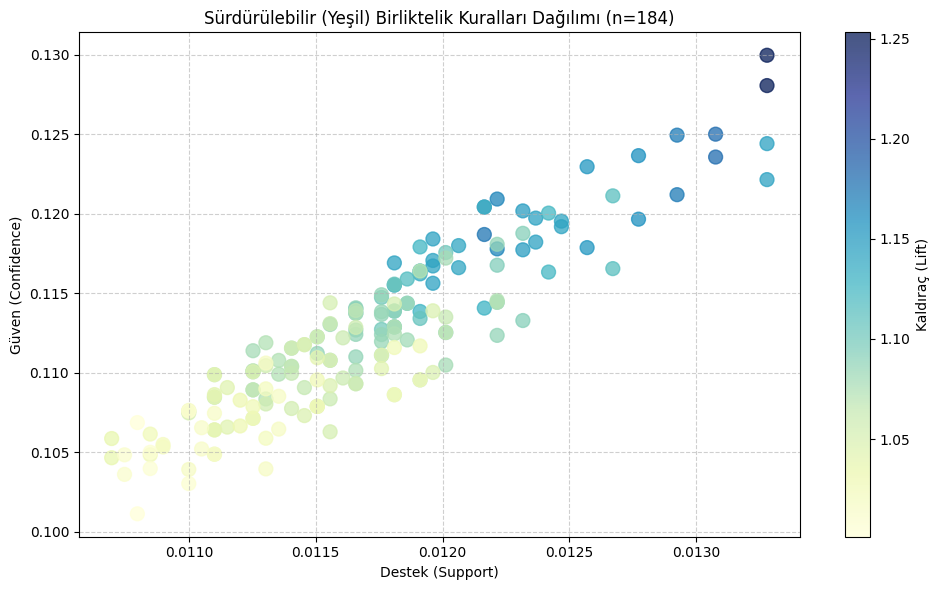


=== AŞAMA B7: CSV + ZIP PAKETLEME ===
[+] en_guclu_genel_kurallar.csv eklendi.
[+] en_guclu_yesil_kurallar.csv eklendi.
[+] yesil_kurallar_dagilim.png eklendi.

[✓] Paket hazır, indiriliyor...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
import matplotlib.pyplot as plt
import zipfile, os
from google.colab import files

print("=== AŞAMA B6: GÖRSELLEŞTİRME ===")
plt.figure(figsize=(10, 6))
sc = plt.scatter(yesil_kurallar['support'], yesil_kurallar['confidence'],
                 c=yesil_kurallar['lift'], cmap='YlGnBu', alpha=0.75, s=100)
plt.colorbar(sc, label='Kaldıraç (Lift)')
plt.title(f'Sürdürülebilir (Yeşil) Birliktelik Kuralları Dağılımı (n={len(yesil_kurallar)})')
plt.xlabel('Destek (Support)'); plt.ylabel('Güven (Confidence)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("yesil_kurallar_dagilim.png", dpi=300)
plt.show()

print("\n=== AŞAMA B7: CSV + ZIP PAKETLEME ===")
strong_rules_yeni.to_csv("en_guclu_genel_kurallar.csv", index=False, encoding='utf-8-sig')
yesil_kurallar.to_csv("en_guclu_yesil_kurallar.csv", index=False, encoding='utf-8-sig')

zip_adi = "proje_b_kolu_cikti_paket.zip"
dosyalar = ["en_guclu_genel_kurallar.csv", "en_guclu_yesil_kurallar.csv", "yesil_kurallar_dagilim.png"]
with zipfile.ZipFile(zip_adi, 'w') as z:
    for d in dosyalar:
        if os.path.exists(d):
            z.write(d)
            print(f"[+] {d} eklendi.")
print("\n[✓] Paket hazır, indiriliyor...")
files.download(zip_adi)